In [ ]:

from transformers import AutoModelForCausalLM
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
import os
from transformers import AutoTokenizer
import math

llama_model = "meta-llama/Llama-2-7b-hf"
model_name = "llama-2-7b-hf"
dtype = torch.float32
# construct the last layer of llama
model = AutoModelForCausalLM.from_pretrained(
    llama_model,
    dtype=dtype,  
    device_map="cuda:0",
    attn_implementation="eager",
)
tokenizer = AutoTokenizer.from_pretrained(
    llama_model,
    use_fast=False,        
)
dataset_name = "pg19"
start = 0
kv = torch.load(f"../{model_name}_{dataset_name}_st{start}.pt", weights_only=False)
model_config = kv["model_config"]
rope_qkv = kv["after_rope"]
inputs = kv["input"]
outputs = kv["output"]
attn_output = kv["attention_output"]
layer_input = kv["layer_input"]
gt_label = kv["gt_label"]
# print("model_config", model_config)
L = model_config.num_hidden_layers
print(model)
device = "cuda:0"

/scratch1/liankewei/miniconda3/envs/nanogpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 291/291 [00:03<00:00, 86.11it/s, Materializing param=model.norm.weight]                              


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
   

In [2]:
V = rope_qkv[L-1]['v'].to(device).to(dtype)  # [B, nh, seq, hd]
V = V[0].permute(1, 0, 2).contiguous()  # [seq, nh, hd]
Wo = model.model.layers[L-1].self_attn.o_proj.weight  # [hidden_size, hidden_size]
print("V shape", V.shape)
V_concate = V.view(V.shape[0], -1)  # [seq, nh*hd] = [seq, hidden_size]
Outputs = V_concate @ Wo.T  # [seq, hidden_size]
print("Outputs shape", Outputs.shape)


W_head = Wo.T.reshape( model_config.num_attention_heads, -1, model_config.hidden_size)  # [nh, hd, hidden_size]
print("V.shape", V.shape, "W_head.shape", W_head.shape)
output_head = V.permute(1, 0, 2) @ W_head  # [nh, seq, hidden_size]
print("output_head shape", output_head.shape)
sum_head = output_head.sum(dim=0)  # [seq, hidden_size]
# assert torch.allclose(Outputs, sum_head, atol=1e-3)
print("max diff", (Outputs - sum_head).abs().max().item())
print("mean diff", (Outputs-sum_head).abs().mean().item())
# diff 0.125, a little big

V shape torch.Size([4096, 32, 128])
Outputs shape torch.Size([4096, 4096])
V.shape torch.Size([4096, 32, 128]) W_head.shape torch.Size([32, 128, 4096])
output_head shape torch.Size([32, 4096, 4096])
max diff 0.0001373291015625
mean diff 6.016524594087969e-07


In [3]:
# ---- 0) 取 V 和 Wo，并强制 fp32 ----
V = rope_qkv[L-1]['v'].to(device)                    # [B, nh, seq, hd]  (dtype可能是 bf16/fp16)
V = V[0].permute(1, 0, 2).contiguous()               # [seq, nh, hd]

Wo = model.model.layers[L-1].self_attn.o_proj.weight # [hidden, hidden]  (一般也是 bf16/fp16)

V_f32  = V.float()                                   # [seq, nh, hd]
WoT_f32 = Wo.T.float()                                # [hidden, hidden]

seq, nh, hd = V_f32.shape
hidden = nh * hd

assert hidden == WoT_f32.shape[0] == WoT_f32.shape[1], \
    f"hidden mismatch: {hidden=} WoT={tuple(WoT_f32.shape)}"

# ---- 1) 直接 concat 后做 matmul（fp32）----
V_concat_f32 = V_f32.view(seq, hidden)               # [seq, hidden]
out_direct_f32 = V_concat_f32 @ WoT_f32              # [seq, hidden]

print("out_direct_f32:", out_direct_f32.shape, out_direct_f32.dtype)

# ---- 2) head-wise 分解（fp32），最后对 head 求和 ----
# Wo^T reshape 成每个 head 的子矩阵: [nh, hd, hidden]
W_head_f32 = WoT_f32.view(nh, hd, hidden).contiguous()

# 每个 head 的贡献: [seq, nh, hidden]
# out_per_head[s, h, :] = V[s,h,:] @ W_head[h,:,:]
out_per_head_f32 = torch.einsum("snh,nhd->snd", V_f32, W_head_f32)

# 最终输出要对 head 求和: [seq, hidden]
out_headsum_f32 = out_per_head_f32.sum(dim=1)

print("out_headsum_f32:", out_headsum_f32.shape, out_headsum_f32.dtype)

# ---- 3) 对比误差（fp32 vs fp32，理论上应接近 0）----
diff = (out_direct_f32 - out_headsum_f32).abs()
print("fp32 diff max:", diff.max().item())
print("fp32 diff mean:", diff.mean().item())


out_direct_f32: torch.Size([4096, 4096]) torch.float32
out_headsum_f32: torch.Size([4096, 4096]) torch.float32
fp32 diff max: 0.0001373291015625
fp32 diff mean: 6.016524594087969e-07


In [4]:
layer = model.model.layers[L-1]
layer.eval()
residual = layer_input[L-1] # [1, seq, hidden_size]
attn_output = attn_output['output'] # [1, seq, nh, hd]
attn_output_concate = attn_output.view(attn_output.shape[0], attn_output.shape[1], -1).contiguous() # [1, seq, hidden_size]
hidden_states = layer.self_attn.o_proj(attn_output_concate)

hidden_states = hidden_states + residual
residual = hidden_states
hidden_states = layer.post_attention_layernorm(hidden_states)
hidden_states = layer.mlp(hidden_states)
hidden_states = residual + hidden_states


KeyError: 'output'

In [14]:
modelNorm = model.model.norm
hidden_states_normed = modelNorm(hidden_states)
print("hidden_states shape", hidden_states.shape)
logits = model.lm_head(hidden_states_normed)
original_logits = outputs['logits'].cpu()
# assert torch.allclose(logits, original_logits, atol=1e-3)
print("max diff", (logits - original_logits).abs().max().item())


hidden_states shape torch.Size([1, 4096, 4096])
max diff 0.01953125


In [44]:
def get_attention_map_after_rope(layer_idx, causal=True, dtype=torch.bfloat16, device="cuda"):
    """
    返回: attn [seq_len, seq_len] (softmax 后)
    """
    Q = rope_qkv[layer_idx]['q']  # [B, nh, seq, hd]
    K = rope_qkv[layer_idx]['k']  # [B, nh, seq, hd]

    q = Q[0].to(dtype).to(device)  # [nh, seq, hd]
    k = K[0].to(dtype).to(device)  # [nh, seq, hd]
    
    hd = q.shape[-1]
    scores = (q @ k.transpose(-1, -2)) / math.sqrt(hd)  # [nh, seq, seq]

    if causal:
        seq = scores.shape[1]
        mask = torch.triu(torch.ones(seq, seq, device=scores.device, dtype=torch.bool), diagonal=1).unsqueeze(0)  # [1, seq, seq]
        scores = scores.masked_fill(mask, float("-inf"))
    # attn = torch.softmax(scores, dim=-1)
    return scores

In [9]:

"""
This exp is for verifying if all KVs are needed.
layer = 10, 20 , 30

We use part of V to simulated original output
budget: 5%, 10%, 25%, 50%, 75%
strategy:
    - recency: only keep the last 10% Vs
    - random: randomly keep 10% Vs
    - clustring: cluster K into 10% clusters, and keep the centroid?
"""
def get_attention_map_after_rope(layer_idx, causal=True, dtype=torch.bfloat16, device="cuda"):
    """
    返回: attn [seq_len, seq_len] (softmax 后)
    """
    Q = rope_qkv[layer_idx]['q']  # [B, nh, seq, hd]
    K = rope_qkv[layer_idx]['k']  # [B, nh, seq, hd]

    q = Q[0].to(dtype).to(device)  # [nh, seq, hd]
    k = K[0].to(dtype).to(device)  # [nh, seq, hd]
    
    hd = q.shape[-1]
    scores = (q @ k.transpose(-1, -2)) / math.sqrt(hd)  # [nh, seq, seq]

    if causal:
        seq = scores.shape[1]
        mask = torch.triu(torch.ones(seq, seq, device=scores.device, dtype=torch.bool), diagonal=1).unsqueeze(0)  # [1, seq, seq]
        scores = scores.masked_fill(mask, float("-inf"))
    # attn = torch.softmax(scores, dim=-1)
    return scores

def gen_mask(layer_idx, pos_list, head_idx, strategy, budget):
    """
    Return mask for alpha_param, with shape [1, n_pos, 4096] or [nh, n_pos, 4096]
    """
    mask = torch.zeros(len(pos_list), 4096, device=device)
    
    visible = int(4096*budget)
    if strategy == "recency":
        for i, pos in enumerate(pos_list):
            if pos > visible:
                mask[i, :pos-visible] = float("-inf")
        mask = mask.unsqueeze(0).expand(len(head_idx), -1, -1)  # [nh, n_pos, 4096]
    elif strategy == "random":
        for i,pos in enumerate(pos_list):
            if pos > visible:
                idx = torch.randperm(pos+1)[:visible]
                idx_list = idx.tolist()
                mask_list = list(set(range(pos+1)) - set(idx_list))
                mask[i, mask_list] = float("-inf")
        mask = mask.unsqueeze(0).expand(len(head_idx), -1, -1)  # [nh, n_pos, 4096]
    elif strategy == "attention_topk":
        attention_score = get_attention_map_after_rope(layer_idx, causal=True, dtype=dtype, device=device)
        # this is logits before softmax, but since we only care about topk, it's fine
        mask = torch.zeros(len(head_idx), len(pos_list), 4096, device=device)
        for head in head_idx:
            attention_score_head = attention_score[head]  # [seq, seq]
            for i,pos in enumerate(pos_list):
                if pos > visible:
                    topk = torch.topk(attention_score_head[pos,:pos+1], k=visible, largest=True).indices
                    idx_list = topk.tolist()
                    mask_list = list(set(range(pos+1)) - set(idx_list))
                    mask[head, i, mask_list] = float("-inf")
    # causal mask
    for i, pos in enumerate(pos_list):
        mask[:, i, pos+1:] = float("-inf")
    return mask  # [n_heads, n_pos, 4096]

def optimize_alpha_star(layer_idx, head_idx, pos_list ,training_steps, lr, mask, device="cuda"):
    """
    head: int, the head to optimize, int or list of int
    pos_list: list of int, the positions to optimize
    """
    if isinstance(head_idx, int):
        head_idx = [head_idx]
        
    # a[n_pos,seq]
    n_pos = len(pos_list)
    # a_param = torch.zeros(len(head_idx), n_pos, 4096, device=device, requires_grad=True)
    a_param = torch.nn.Parameter(torch.randn(len(head_idx), n_pos, 4096, device=device) * 0.1)
    # attention_score = get_attention_map_after_rope(layer_idx, causal=True, dtype=dtype, device=device)
    # a_param = attention_score[head_idx].to(device)[:, pos_list, :].clone().detach().requires_grad_(True)
    a_param.retain_grad()
    
    opt = torch.optim.Adam([a_param], lr=lr)
    
    # compute the constant part
    residual_attn_in = layer_input[layer_idx][0,pos_list].to(device) # [n_pos, hidden_size]
    original = attn_output[layer_idx]['output'][0,pos_list].permute(1,0,2).to(device) # [nh, n_pos, hd]
    V_head = rope_qkv[layer_idx]['v'].to(device)[0][head_idx]  # [nh, seq, hd]
    layer = model.model.layers[layer_idx]
    
    with torch.no_grad():
        # calculate gt distribution p*
        output = original.clone() # [nh, n_pos, hd]
        hidden = layer.self_attn.o_proj(output.permute(1,0,2).reshape(len(pos_list), -1)) # [n_pos, hidden_size]
        hidden = hidden + residual_attn_in # add residual
        # hidden = modelNorm(hidden)
        gt_logits = model.lm_head(hidden) # [n_pos, vocab_size]
        p_teacher = F.softmax(gt_logits.float(), dim=-1).detach()  # [n_pos, vocab_size]
        logp_teacher = F.log_softmax(gt_logits.float(), dim=-1).detach()  # [n_pos, vocab_size]
    losses = []
    p_alpha = 0
    for step in range(training_steps):
        
        alpha = F.softmax(a_param + mask, dim=-1)  
        # logits = function(alpha, head_idx, V_head, pos_list, original, residual_attn_in)
        nan_mask = torch.isnan(alpha)
        V_new = alpha @ V_head.float() # alpha [nh, n_pos, seq] @ V_head [nh, seq, hd] -> [nh, n_pos, hd]
        
        V_new = V_new.to(original.dtype)
        output = original.clone()
        output[head_idx] = V_new.to(V_head.dtype)
        hidden = output.permute(1,0,2).reshape(len(pos_list), -1) # [n_pos, hidden_size]
        
        hidden = layer.self_attn.o_proj(hidden) # [n_pos, hidden_size]
        hidden = hidden + residual_attn_in # add residual
        # hidden = modelNorm(hidden)
        hidden = model.lm_head(hidden) # [n_pos, vocab_size]
        logits = hidden
        p_alpha = F.softmax(logits.float(), dim=-1) # [n_pos, vocab_size]
        logp_student = F.log_softmax(logits.float(), dim=-1)
        # KL-Divergence loss (CE loss)
        loss = (p_teacher * (logp_teacher-logp_student)).sum(dim=-1).mean()
        losses.append(loss.item())
        if step % 100 == 0:
            print("step", step, "loss:", loss.item())
        opt.zero_grad()
        loss.backward()
        opt.step()
    # verify KKT conditions
    alpha = F.softmax(a_param + mask, dim=-1)
    
    return alpha, p_alpha, p_teacher, losses

layer_idx = 30
head_idx = list(range(32)) # [0,...,31]
print("Optimizing alpha_star for head_idx", head_idx)
pos_list = list(range(4096-64, 4096))
strategy = "attention_topk"
budget = 0.005
mask = gen_mask(layer_idx, pos_list, head_idx=head_idx, strategy=strategy, budget=budget)
alpha, p_alpha, p_teacher, loss = optimize_alpha_star(
    layer_idx=layer_idx, head_idx=head_idx, pos_list=pos_list, training_steps=10000, lr=0.05, mask=mask, device=device)

# print( "final loss", loss[-1])

Optimizing alpha_star for head_idx [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
step 0 loss: 0.21607336401939392
step 100 loss: 0.0009885814506560564
step 200 loss: 0.0005006809951737523
step 300 loss: 0.0003275583148933947
step 400 loss: 0.00023136305389925838
step 500 loss: 0.00017176114488393068
step 600 loss: 0.0001350927195744589
step 700 loss: 0.00011029660527128726
step 800 loss: 9.19306548894383e-05
step 900 loss: 7.845904474379495e-05
step 1000 loss: 6.847249460406601e-05
step 1100 loss: 6.05370951234363e-05
step 1200 loss: 5.407226854003966e-05
step 1300 loss: 4.873282523476519e-05
step 1400 loss: 4.41668089479208e-05
step 1500 loss: 4.019984771730378e-05
step 1600 loss: 3.66507338185329e-05
step 1700 loss: 3.344954166095704e-05
step 1800 loss: 3.0720057111466303e-05
step 1900 loss: 2.844481059582904e-05
step 2000 loss: 2.648423469508998e-05
step 2100 loss: 2.4789267627056688e-05
step 2200 loss: 2.32791

another implementation of solving. Worse than SGD.

In [ ]:
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F

def optimize_alpha_star_fw(layer_idx, head_idx, pos_list, training_steps, lr, mask, device="cuda"):
    """
    Frank–Wolfe (Conditional Gradient) on alpha in product of simplices with masking.
    Interface compatible with optimize_alpha_star.

    Args:
        lr: ignored (kept for interface compatibility). Step-size uses default FW schedule.
        mask: [1,n_pos,seq] or [nh,n_pos,seq] with 0 or -inf (disallowed)
    Returns:
        alpha: [nh, n_pos, seq]
        p_alpha: [n_pos, vocab_size] (student dist from last iter)
        p_teacher: [n_pos, vocab_size]
        losses: list[float]
    """
    if isinstance(head_idx, int):
        head_idx = [head_idx]

    n_pos = len(pos_list)
    nh = len(head_idx)
    seq = mask.shape[-1]

    # Broadcast mask to [nh, n_pos, seq]
    if mask.dim() == 3 and mask.shape[0] == 1:
        mask_h = mask.expand(nh, -1, -1).to(device)
    elif mask.dim() == 3 and mask.shape[0] == nh:
        mask_h = mask.to(device)
    else:
        raise ValueError(f"mask shape must be [1,n_pos,seq] or [nh,n_pos,seq], got {tuple(mask.shape)}")

    allowed = torch.isfinite(mask_h)  # [nh,n_pos,seq]

    # ----- constants (same as your GD version) -----
    residual_attn_in = layer_input[layer_idx][0, pos_list].to(device)  # [n_pos, hidden_size]
    original = attn_output[layer_idx]['output'][0, pos_list].permute(1, 0, 2).to(device)  # [nh_total, n_pos, hd]
    V_head = rope_qkv[layer_idx]['v'].to(device)[0][head_idx]  # [nh, seq, hd]
    layer = model.model.layers[layer_idx]

    with torch.no_grad():
        out_full = original.clone()
        hidden = layer.self_attn.o_proj(out_full.permute(1, 0, 2).reshape(n_pos, -1))
        hidden = hidden + residual_attn_in
        gt_logits = model.lm_head(hidden)
        p_teacher = F.softmax(gt_logits.float(), dim=-1).detach()
        logp_teacher = F.log_softmax(gt_logits.float(), dim=-1).detach()

    # ----- init alpha: uniform over allowed per (h,pos) -----
    alpha = torch.zeros((nh, n_pos, seq), device=device, dtype=torch.float32)
    denom = allowed.sum(dim=-1, keepdim=True).clamp_min(1)
    alpha[allowed] = 1.0
    alpha = alpha / denom

    losses = []
    p_alpha = None

    # optional early-stop based on FW gap
    gap_tol = 1e-9

    for t in range(training_steps):
        alpha_var = alpha.detach().requires_grad_(True)

        # forward
        V_new = torch.matmul(alpha_var, V_head.float()).to(original.dtype)  # [nh,n_pos,hd]
        out = original.clone()
        out[head_idx] = V_new.to(V_head.dtype)

        hidden = out.permute(1, 0, 2).reshape(n_pos, -1)
        hidden = layer.self_attn.o_proj(hidden)
        hidden = hidden + residual_attn_in
        logits = model.lm_head(hidden)

        logp_student = F.log_softmax(logits.float(), dim=-1)
        loss = (p_teacher * (logp_teacher - logp_student)).sum(dim=-1).mean()

        loss.backward()
        g = alpha_var.grad  # [nh,n_pos,seq]

        # mask forbidden coords in the LMO: set grad to +inf so argmin never picks them
        with torch.no_grad():
            g_masked = g.clone()
            g_masked[~allowed] = float("inf")

            # LMO on simplex: s = one-hot at argmin grad for each (h,pos)
            idx = torch.argmin(g_masked, dim=-1, keepdim=True)  # [nh,n_pos,1]
            s = torch.zeros_like(alpha)
            s.scatter_(-1, idx, 1.0)
            s = s * allowed  # just in case (should already be allowed)

            # Frank–Wolfe gap certificate: <alpha - s, g> = <alpha,g> - min(g)
            # compute per (h,pos) then average
            min_g = torch.gather(g_masked, -1, idx).squeeze(-1)  # [nh,n_pos]
            alpha_dot_g = (alpha * g).sum(dim=-1)               # [nh,n_pos]
            fw_gap = (alpha_dot_g - min_g).mean().item()

            # Step size: standard diminishing schedule for convex smooth FW
            gamma = 2.0 / (t + 2.0)  # t=0 -> 1.0, then decreases

            # update
            alpha = (1.0 - gamma) * alpha + gamma * s

            # keep feasibility (numerical safety)
            alpha = alpha * allowed
            alpha = alpha / alpha.sum(dim=-1, keepdim=True).clamp_min(1e-20)

        losses.append(loss.item())
        if t % 100 == 0:
            print("step", t, "loss:", loss.item(), "fw_gap:", fw_gap)

        # cache p_alpha at last iter
        if t == training_steps - 1:
            with torch.no_grad():
                p_alpha = F.softmax(logits.float(), dim=-1).detach()

        # early stop if really close to optimum
        if fw_gap < gap_tol and t > 50:
            print(f"Early stop at step {t}: fw_gap={fw_gap:.3e}")
            with torch.no_grad():
                p_alpha = F.softmax(logits.float(), dim=-1).detach()
            break

    return alpha, p_alpha, p_teacher, losses
layer_idx = 30
head_idx = list(range(32))
pos_list = list(range(4096-64, 4096))

mask = torch.zeros(len(pos_list), 4096, device=device)
for i, pos in enumerate(pos_list):
    mask[i, pos+1:] = float("-inf")
mask = mask.unsqueeze(0)  # [1, n_pos, 4096]

alpha, p_alpha, p_teacher, losses = optimize_alpha_star_fw(
    layer_idx=layer_idx,
    head_idx=head_idx,
    pos_list=pos_list,
    training_steps=10000,
    lr=0.5,            # eta
    mask=mask,
    device=device
)
print("final loss", losses[-1])

In [10]:

def verify_KKT(layer_idx, head_idx, alpha, p_alpha, p_teacher, V_head):
    """
    alpha: [nh, n_pos, seq]
    p_alpha: [n_pos, vocab_size]
    p_teacher: [n_pos, vocab_size]
    """
    head_id = torch.randint(0, alpha.shape[0], size=(1,)).item()
    true_head_id = head_idx[head_id]
    Wo = model.model.layers[layer_idx].self_attn.o_proj.weight  # [hidden_size, hidden_size]
    WoT = Wo.T.reshape( model_config.num_attention_heads, -1, model_config.hidden_size)  # [nh, hd, hidden_size]
    V = V_head[head_id] # [seq,hd]
    W_head = WoT[true_head_id] # [hd, hidden_size]
    VW = V @ W_head # [seq, hidden_size]
    VW = VW @ model.lm_head.weight.T # [seq, vocab_size]
    r1_list = []
    r2_list = []
    for pos in range(alpha.shape[1]):
        alpha_pos = alpha[head_id][pos] # [seq]
        det = (p_alpha[pos] - p_teacher[pos]) # [vocab_size]
        eps = 1e-9
        sup = []
        not_sup = []
        for i in range(len(alpha_pos)):
            if alpha_pos[i] > eps:
                # support vector
                sup.append((VW[i]*det).sum())
            else :
                not_sup.append((VW[i]*det).sum())
        sup = torch.stack(sup, dim=0)
        avg = sup.mean(dim=0)
        weighted_avg = (alpha_pos[alpha_pos>eps] * sup).sum() / alpha_pos[alpha_pos>eps].sum()
        
        # support set should have same VW * (p(alpha)-p*)
        r1 = (sup - weighted_avg).abs().max().item()
        r1_list.append(r1)
        
        if len(not_sup) != 0:
            # not support > avg
            # if this is significant < 0, then KKT conditions are violated
        
            not_sup = torch.stack(not_sup, dim=0)
            r2 = (not_sup - weighted_avg).min().item()
        else :
            r2 = 0
        r2_list.append(r2)
        
        # print(f"KKT check for head {true_head_id} pos {pos}: max|sup-avg|={r1:.6f}, min(not_sup-avg)={r2:.6f}")
    print(f"KKT check for head {true_head_id}: max|sup-avg|={max(r1_list):.6f}, avg|sup-avg|={sum(r1_list)/len(r1_list):.6f}")
    print(f"KKT check for head {true_head_id}: min(not_sup-avg)={min(r2_list):.6f}, avg(not_sup-avg)={sum(r2_list)/len(r2_list):.6f}")
V_head = rope_qkv[layer_idx]['v'].to(device)[0][head_idx]  # [nh, seq, hd]
verify_KKT(layer_idx, head_idx, alpha, p_alpha, p_teacher, V_head)

KKT check for head 24: max|sup-avg|=0.000765, avg|sup-avg|=0.000067
KKT check for head 24: min(not_sup-avg)=-0.000592, avg(not_sup-avg)=-0.000073


In [12]:

# for layer_idx in [10,20,30]:
head_idx = list(range(32)) # [0,...,31]
pos_list = list(range(4096-64, 4096))
result = {}
strategy = "attention_topk"
for layer_idx in [30]:
    for budget in [0.0005,0.001, 0.005 ,0.01 , 0.05]:
        mask = gen_mask(layer_idx, pos_list, head_idx=head_idx, strategy=strategy, budget=budget)
        print(f"Optimizing alpha_star for layer {layer_idx}, budget {budget}")
        alpha, p_alpha, p_teacher, loss = optimize_alpha_star(
            layer_idx=layer_idx, head_idx=head_idx, pos_list=pos_list, training_steps=10000, lr=0.05, mask=mask, device=device)
        print( f"final loss for layer {layer_idx} with budget {budget}: ", loss[-1])
        result[(layer_idx, budget)] = (alpha, p_alpha, p_teacher, loss)
    
    

Optimizing alpha_star for layer 30, budget 0.001
step 0 loss: 0.09451816231012344
step 100 loss: 0.000401827332098037
step 200 loss: 0.00022165340487845242
step 300 loss: 0.00016013352433219552
step 400 loss: 0.00012907537166029215
step 500 loss: 0.00011096030357293785
step 600 loss: 9.916145063471049e-05
step 700 loss: 9.085293277166784e-05
step 800 loss: 8.481063559884205e-05
step 900 loss: 8.019357483135536e-05
step 1000 loss: 7.662871212232858e-05
step 1100 loss: 7.370779349002987e-05
step 1200 loss: 7.136465865187347e-05
step 1300 loss: 6.939342711120844e-05
step 1400 loss: 6.773672794224694e-05
step 1500 loss: 6.631130236200988e-05
step 1600 loss: 6.506947102025151e-05
step 1700 loss: 6.396522803697735e-05
step 1800 loss: 6.297670188359916e-05
step 1900 loss: 6.209516141097993e-05
step 2000 loss: 6.132909038569778e-05
step 2100 loss: 6.061818930902518e-05
step 2200 loss: 5.99667000642512e-05
step 2300 loss: 5.9388290537754074e-05
step 2400 loss: 5.885598875465803e-05
step 2500 lo

KeyboardInterrupt: 

Budget 0.25: final loss 0.000012
Budget 0.5: final loss 0.000004
Budget 1.0: final loss 0.000036
filtered_x [4032 4033 4035 4036 4037 4038 4039 4040 4041 4042 4043 4044 4045 4046
 4047 4048 4049 4050 4051 4052 4053 4054 4055 4056 4057 4058 4059 4060
 4062 4063 4065 4066 4067 4068 4069 4070 4071 4072 4073 4074 4075 4076
 4077 4078 4079 4080 4081 4082 4083 4084 4085 4086 4087 4088 4089 4090
 4091 4092 4093 4094]


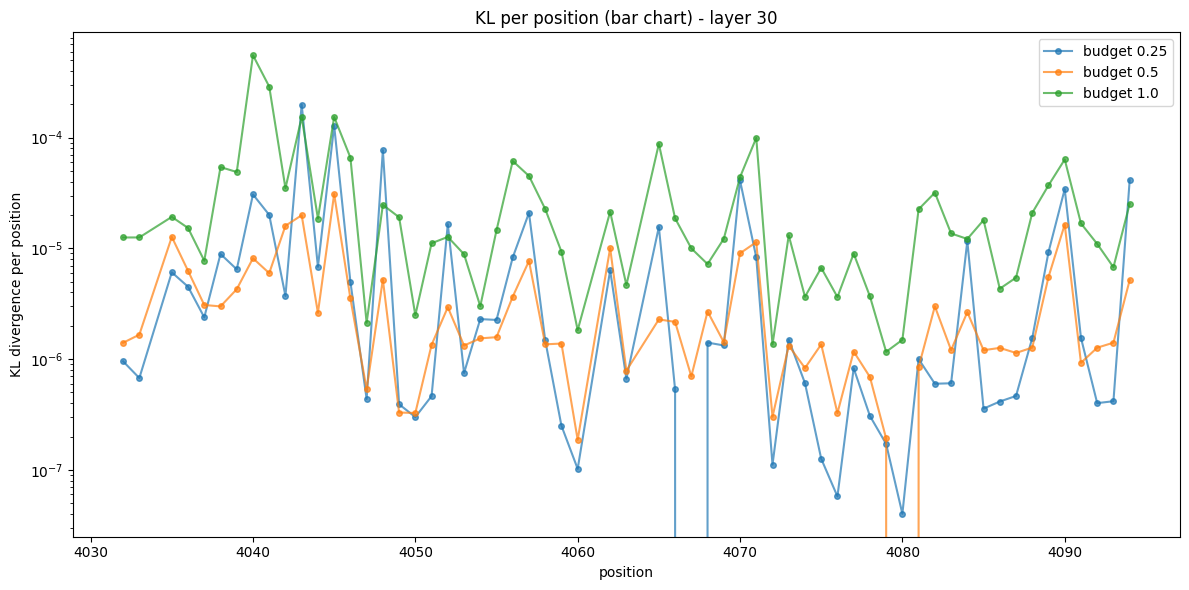

In [24]:
import matplotlib.pyplot as plt
import numpy as np
budgets = [ 0.25, 0.5, 1.0]

plt.figure(figsize=(12,6))

x = np.array(pos_list)  # positions
all_losses = []
for j, budget in enumerate(budgets):
    alpha, p_alpha, p_teacher, loss = result[(layer_idx,budget)]
    print(f"Budget {budget}: final loss {loss[-1]:.6f}")
    eps = 1e-12
    logp_teacher = torch.log(p_teacher + eps)
    loss_per_pos = (p_teacher * (logp_teacher - torch.log(p_alpha + eps))).sum(dim=-1).detach()  # [n_pos]
    y = loss_per_pos.float().cpu().numpy()
    all_losses.append(y)
max_loss_per_pos = np.max(all_losses, axis=0)
threshold = 5e-7
mask = max_loss_per_pos > threshold 
filtered_x = np.array(pos_list)[mask]
print("filtered_x", filtered_x)
for j, budget in enumerate(budgets):
    filtered_y = all_losses[j][mask]
    
    plt.plot(filtered_x, filtered_y, 'o-', alpha=0.7, markersize=4, label=f"budget {budget}")
plt.xlabel("position")
plt.ylabel("KL divergence per position")
plt.yscale("log")  # 你之前用 log，这里也保留；不需要可删
plt.title(f"KL per position (bar chart) - layer {layer_idx}")
plt.legend()
plt.tight_layout()
plt.show()

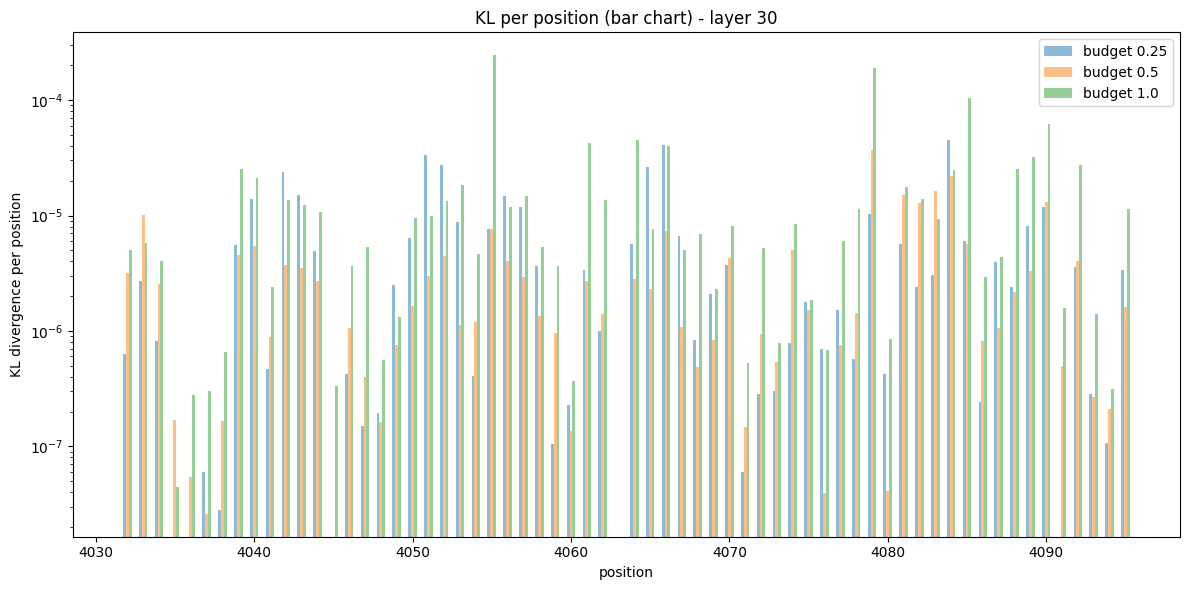

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

layer_idx = 30
budgets = [ 0.25, 0.5, 1.0]

plt.figure(figsize=(12,6))

x = np.array(pos_list)  # positions
bar_w = 0.18 * (x[1] - x[0] if len(x) > 1 else 1.0)  # 柱宽，按步长自适应

for j, budget in enumerate(budgets):
    alpha, p_alpha, p_teacher, loss = result[(layer_idx, budget)]
    eps = 1e-12
    logp_teacher = torch.log(p_teacher + eps)
    loss_per_pos = (p_teacher * (logp_teacher - torch.log(p_alpha + eps))).sum(dim=-1).detach()  # [n_pos]
    y = loss_per_pos.float().cpu().numpy()

    plt.bar(x + (j - (len(budgets)-1)/2) * bar_w, y, width=bar_w, alpha=0.5, label=f"budget {budget}")

plt.xlabel("position")
plt.ylabel("KL divergence per position")
plt.yscale("log")  # 你之前用 log，这里也保留；不需要可删
plt.title(f"KL per position (bar chart) - layer {layer_idx}")
plt.legend()
plt.tight_layout()
plt.show()

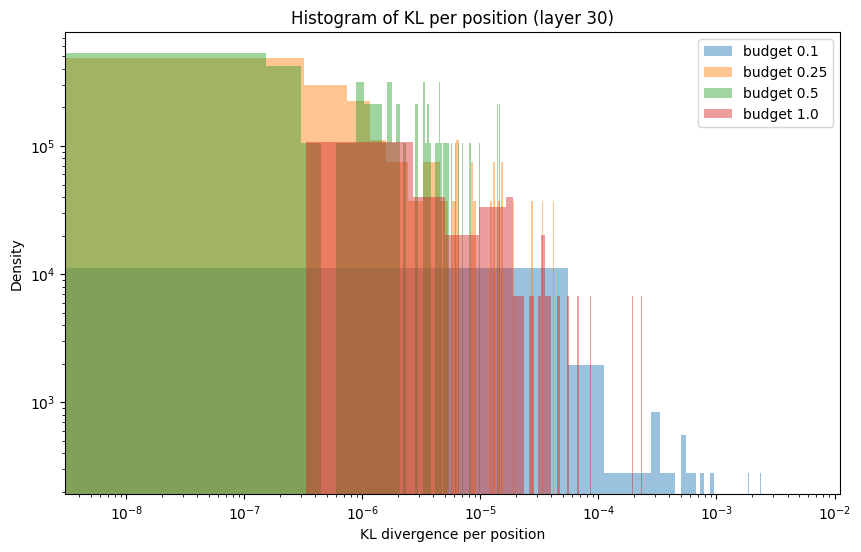

In [24]:
plt.figure(figsize=(10,6))

for budget in [0.1, 0.25, 0.5, 1.0]:
    alpha, p_alpha, p_teacher, loss = result[(layer_idx, budget)]
    logp_teacher = torch.log(p_teacher + 1e-20)
    loss_per_pos = (p_teacher * (logp_teacher - torch.log(p_alpha + 1e-20))).sum(dim=-1).detach()  # [n_pos]
    x = loss_per_pos.float().cpu().numpy()

    plt.hist(x, bins=100, alpha=0.45, density=True, label=f"budget {budget}")

plt.xlabel("KL divergence per position")
plt.xscale("log")  # KL divergence often has a long tail, log scale can help visualization; 不需要可删
plt.ylabel("Density")
plt.yscale("log")  # 如果觉得难看可以去掉
plt.title(f"Histogram of KL per position (layer {layer_idx})")
plt.legend()
plt.show()

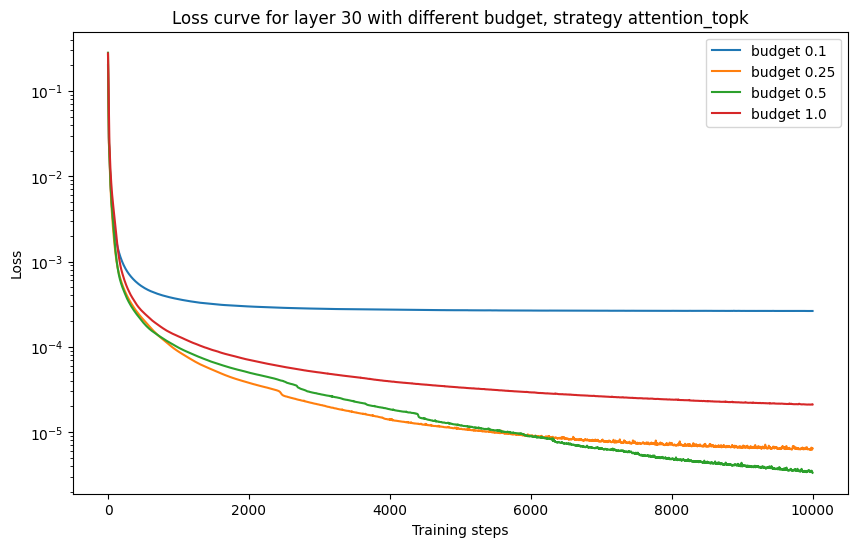

In [22]:
# plot loss curve for different budget
for layer_idx in [30]:
    plt.figure(figsize=(10,6))
    for budget in [ 0.1, 0.25, 0.5, 1.0]:
        alpha, p_alpha, p_teacher, loss = result[(layer_idx, budget)]
        plt.plot(loss, label=f"budget {budget}")
    plt.title(f"Loss curve for layer {layer_idx} with different budget, strategy {strategy}")
    plt.xlabel("Training steps")
    plt.ylabel("Loss")
    # log scale for y axis
    plt.yscale("log")
    plt.legend()
    plt.show()
    

KL(attnetion score||a_star) 5.219204902648926


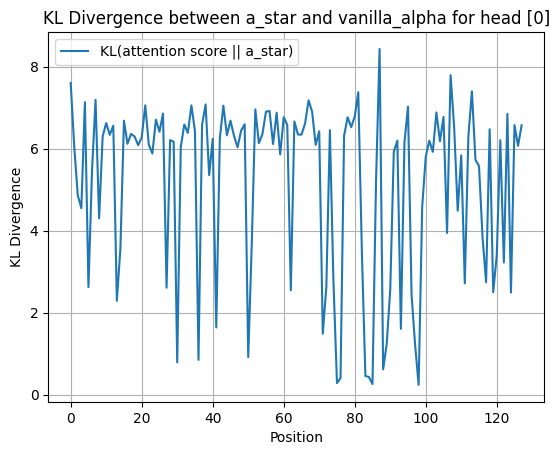

KL(a_star || a_star_2) 0.9319888353347778


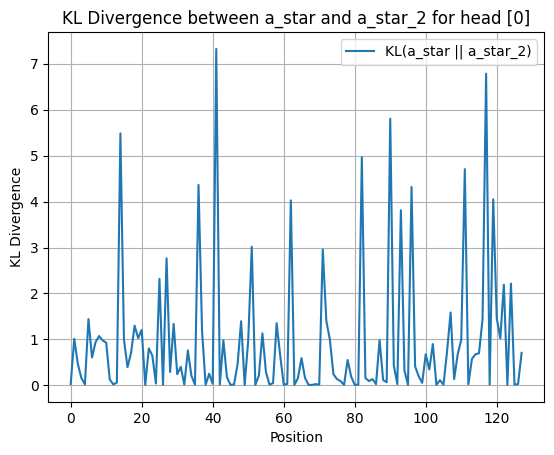

In [64]:
def KL_divergence(p, q):
    eps = 1e-7
    p = p.clamp_min(eps)
    q = q.clamp_min(eps)
    kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
    return kl_pq, kl_qp
head_idx = [0]
sf_attn_score = F.softmax(attention_score[head_idx][:, pos_list,:], dim=-1)
kl_pq, kl_qp = KL_divergence(sf_attn_score[0],a_star[head_idx][0])
print("KL(attnetion score||a_star)", kl_pq.mean().item())
# plot the KL divergence across the sequence
plt.plot(kl_pq.cpu().numpy(), label="KL(attention score || a_star)")
# plt.plot(kl_qp.cpu().numpy(), label="KL(vanilla_alpha || a_star)")
plt.title(f"KL Divergence between a_star and vanilla_alpha for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid()
plt.show()

kl_pq, kl_qp = KL_divergence(a_star[head_idx][0], a_star_2[head_idx][0])
print("KL(a_star || a_star_2)", kl_pq.mean().item())
# print("KL(a_star_2 || a_star)", kl_qp.mean().item())
plt.plot(kl_pq.cpu().numpy(), label="KL(a_star || a_star_2)")
plt.title(f"KL Divergence between a_star and a_star_2 for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid()
plt.show()

In [14]:

def topk_overlap(p, q, topk=10):
    p_topk_indices = torch.topk(p, k=topk, dim=-1).indices  # [n_pos, topk]
    q_topk_indices = torch.topk(q, k=topk, dim=-1).indices  # [n_pos, topk]

    overlap_counts = []

    for i in range(p_topk_indices.shape[0]):
        overlap = set(p_topk_indices[i].tolist()) & set(q_topk_indices[i].tolist())
        overlap_counts.append(len(overlap))
    print("overlap_counts", overlap_counts)
    return overlap_counts

topk=5
overlap_counts = topk_overlap(a_star, vanilla_alpha, topk=topk) 
print("Average top-{} overlap: {}".format(topk, sum(overlap_counts)/len(overlap_counts)/topk))
# print("Average top-{} overlap: {}".format(topk, topk_overlap(a_star, a_star_2, topk=topk)))



overlap_counts [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Average top-5 overlap: 0.0125


In [ ]:
torch.set_printoptions(sci_mode=False)

vanilla = outputs["logits"]
vanilla_logits = vanilla[0][pos_list]
loss_baseline = F.cross_entropy(vanilla_logits.float(), gt_label[0, pos_list].to(vanilla_logits.device), reduction='none')
print("baseline loss", loss_baseline.mean().item())

device='cuda'
a_star = a_star.to(device)
residual_attn_in = layer_input[L-1][0,pos_list].to(device) # [n_pos, hidden_size]
original = attn['output'][0,pos_list].permute(1,0,2).to(device) # [nh, n_pos, hd]
V_head = rope_qkv[L-1]['v'].to(device)[0][head_idx]  # [B, nh, seq, hd]
Wo = last_layer_param['self_attn.o_proj.weight'].to(device)
Wlm = kv["Wlm"].to(device)

logits = mlp_forward(a_star, head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm)
loss_mix = F.cross_entropy(logits.float(), gt_label[0, pos_list].to(logits.device), reduction='none')
print("mix loss", loss_mix.mean().item())

logits_2 = mlp_forward(a_star_2.to(device), head_idx, V_head, pos_list, original, residual_attn_in, Wo, Wlm)
loss_mix_2 = F.cross_entropy(logits_2.float(), gt_label[0, pos_list].to(logits_2.device), reduction='none')
print("mix_2 loss", loss_mix_2.mean().item())

eps = 1e-5

# print(loss_baseline[diff_cos_pos].mean().item(), loss_baseline[diff_cos_pos].max().item(),loss_baseline)
print(loss_mix[diff_cos_pos].mean().item(), loss_mix[diff_cos_pos].max().item(),loss_mix[diff_cos_pos])

baseline loss 1.7316447496414185
mix loss 1.6329621076583862
mix_2 loss 1.633148431777954
0.03299250453710556 0.1810423582792282 tensor([0.0075, 0.1810, 0.0064, 0.0017, 0.0012, 0.0002], device='cuda:0',
       grad_fn=<IndexBackward0>)


Cluster sizes:
[384 175 446 257 170 379 174 182 314 166 301 331 139 361 132 185]
tensor([[3.5736e-02, 2.6822e-06, 3.9339e-06, 6.6996e-04, 3.3200e-05, 8.8036e-05,
         2.1279e-05, 3.3379e-06, 2.8610e-06, 5.8293e-05, 4.9472e-06, 1.6999e-04,
         9.0003e-06, 1.3947e-05, 8.2850e-06, 1.1325e-06, 1.1921e-06, 4.2319e-06,
         1.7881e-06, 1.3113e-06],
        [9.6191e-02, 1.6987e-05, 2.5332e-05, 1.7776e-03, 1.3113e-04, 3.6788e-04,
         1.0502e-04, 2.1696e-05, 1.6809e-05, 9.6321e-05, 2.9504e-05, 6.4087e-04,
         4.5002e-05, 8.2731e-05, 5.0008e-05, 8.1658e-06, 1.2040e-05, 2.9266e-05,
         1.2696e-05, 1.6093e-05],
        [4.4580e-01, 1.2279e-05, 4.5538e-05, 1.3561e-03, 1.0836e-04, 3.4285e-04,
         1.3530e-04, 3.0935e-05, 1.9193e-05, 3.8099e-04, 2.7835e-05, 3.2592e-04,
         2.9981e-05, 5.9128e-05, 3.0816e-05, 8.9407e-06, 1.7345e-05, 9.4473e-05,
         2.7835e-05, 3.5167e-05]], device='cuda:0')
Cluster a_star entrophy 0.30542635917663574
Cluster attention score en

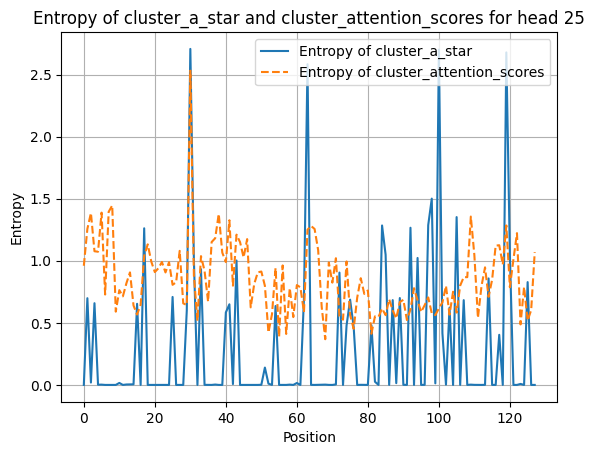

In [ ]:
from matplotlib import axis
from sklearn.cluster import KMeans
import numpy as np
def clustering(layer_idx, head_idx=0, key_type='k', n_clusters=5):
    key = rope_qkv[layer_idx][key_type] # [B,nh,seq_len,hd]
    specific_head_key = key[0, head_idx, :, :] # [seq_len, head_dim]
    key = F.normalize(specific_head_key.float(), dim=-1).cpu().numpy()
    labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(key)
    print("Cluster sizes:")
    print(np.bincount(labels))

    return labels

num_clusters = 16
labels = clustering(layer_idx=L-1, head_idx=head_idx, key_type='k', n_clusters=16)
# plot the inter-cluster attention score concentration
cluster_a_star = []
cluster_attention_scores = []
for i in range(num_clusters):
    cluster_positions = np.where(labels == i)[0]
    cluster_a_star.append(a_star[:, cluster_positions].sum(axis=1))  # [n_pos, cluster_len] -> [n_pos]
    cluster_attention_scores.append(vanilla_alpha[:, cluster_positions].sum(axis=1))  # [n_pos]
# plot the entropy of cluster_a_star and cluster_attention_scores
cluster_a_star = torch.stack(cluster_a_star, dim=1)  # [n_pos, num_clusters]
cluster_attention_scores = torch.stack(cluster_attention_scores, dim=1)  # [n_pos, num_clusters]
cluster_a_star_entrophy = -(cluster_a_star * cluster_a_star.clamp_min(1e-8).log()).sum(dim=-1)
cluster_attention_entrophy = -(cluster_attention_scores * cluster_attention_scores.clamp_min(1e-8).log()).sum(dim=-1)
print("Cluster a_star entrophy", cluster_a_star_entrophy.mean().item())
print("Cluster attention score entrophy", cluster_attention_entrophy.mean().item())
plt.plot(cluster_a_star_entrophy.cpu().numpy(), label="Entropy of cluster_a_star", linestyle='-', color='C0')
plt.plot(cluster_attention_entrophy.cpu().numpy(), label="Entropy of cluster_attention_scores", color='C1', linestyle='--')
plt.title(f"Entropy of cluster_a_star and cluster_attention_scores for head {head_idx}")
plt.xlabel("Position")
plt.ylabel("Entropy")
plt.legend()
plt.grid()
plt.show()